# Principal Component Analysis (PCA)

PCA is an unsupervised technique that processes unlabelled data to restructure the columns of a dataframe. The primary use of PCA is dimensionality reduction, which reduces the number of columns while trying to lose as little detail as possible. This streamlining of data has a notable secondary effect: it can reduce noise. Noise in data refers to random variations that obscure underlying patterns or signals, making it harder to extract meaningful information.

In this project, we don't have many columns, so dimensionality reduction isn't a major concern. However, this technique will be particularly useful in our next project, supervised machine learning. For now, you'll find that the noise reduction achieved through PCA helps to create better clusters, demonstrating why PCA is such a valuable unsupervised learning tool.

---
##1.&nbsp; Import libraries and files 💾

In [31]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(transform_output="pandas")

In [32]:
# Get the spreadsheet ID and name
sheet_id = "1gYXqOBLEYIr99YmKGq2nIvK3CJmoWzsvwfwR9adfo2w"
sheet_name = "18136796"

# Construct the URL to the CSV export of the spreadsheet
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_name}"

# Read the CSV data into a Pandas DataFrame
# Set the index column to `student` and only read the first 15 rows
foods_df = pd.read_csv(url,
                       index_col="student")

# Drop the `favorite_color` column
foods_df = foods_df.drop(columns="favorite_color")

---
##2.&nbsp; Scale the data 📐
In this notebook, we are only using the MinMaxScaler to keep the code simple and focus on PCA. However, we encourage you to experiment with other scalers, as they can have a impact.

In [33]:
# Initialise the transformer (optionally, set parameters)
my_min_max = MinMaxScaler()

# Use the transformer to transform the data
scaled_features_df = my_min_max.fit_transform(foods_df)

---
##3.&nbsp; PCA ⚙️
As you saw on the LMS, PCA creates as many principal components as the original DataFrame has columns. We then need to decide how many of these components to keep. Before we do that, let's look at how PCA transforms our DataFrame.

In [34]:
# Initialise the PCA object
pca = PCA()

# Fit the PCA object to the data
pca.fit(scaled_features_df)

# Transform scaled_features_df based on the fit calculations
pca_basic_df = pca.transform(scaled_features_df)

pca_basic_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9
student,,,,,,,,,,
Alexandra,0.791544,-0.013019,-1.141658,0.035853,-0.155952,0.101268,-0.067188,0.075349,0.018000,0.049562
Andrea,-0.049550,0.820885,-0.353933,0.542393,0.377203,-0.130496,-0.073656,0.043619,0.023637,-0.057998
Daniel,0.686774,0.839755,0.352403,-0.423750,-0.061842,0.240311,0.319581,0.086818,-0.034673,-0.002020
Josef,0.627075,-0.944560,0.037933,-0.257967,0.107956,-0.192858,0.199884,0.017786,0.012187,-0.026773
Kaj,1.005751,-0.087092,0.307003,0.411140,-0.324927,-0.174651,-0.019193,-0.199877,0.072476,-0.014589
Katherine,0.369758,-0.440530,0.342519,0.127094,0.528051,0.459197,-0.173156,-0.081689,-0.026757,0.010779
Leslie,-0.340745,-0.239646,-0.294414,-0.069526,-0.068146,-0.179807,-0.015188,-0.037138,-0.197685,-0.020505
Merry,-0.742523,0.417591,0.151973,0.136223,-0.010156,-0.100662,0.080915,-0.257022,-0.021292,0.056007
Perry,-1.035180,-0.144931,-0.214252,-0.283412,-0.436968,0.365140,-0.057370,-0.062502,0.053461,-0.047467


> You may notice that we have the same amount of columns as before but we have lost the column names. This is because the columns are now principal components and not the original features (brocolli, burgers, etc...). Principal components are an abstraction of the original features, capturing the most significant patterns and trends within the data. They are like new axes along which the data is spread out, representing directions of maximum variance. The first principal component captures the largest amount of variance, followed by the second, and so on.

###3.1.&nbsp; Identifying the most informative principal components
Principal component analysis (PCA) assumes that variance is information. This means that PCA believes that the directions in which the data varies the most are the most important.

When we fit PCA to our data, it calculates all of the principal components. We can see how much variance each principal component explains using the `explained_variance_ratio_` attribute.
> The principal components are ranked in order of decreasing variance, with the first principal component explaining the most variance in the data

In [35]:
# Get the variance explained by each principal component
explained_variance_array = pca.explained_variance_ratio_

explained_variance_array

array([0.36750845, 0.19249008, 0.15946553, 0.13408911, 0.06318577,
       0.04111646, 0.02307594, 0.0141886 , 0.00398162, 0.00089843])

To determine how many principal components to keep, we can use one of two methods:

- **Elbow method**: This is a more manual approach where we plot the explained variance of each principal component against its index. The elbow point is the point at which the explained variance starts to drop off significantly. This is the point at which it is no longer worth retaining any more principal components, as they are not explaining much additional variance.
- **Cumulative explained variance**: This is a more automated approach where SKLearn calculates how many principal components contain a given amount of variance, such as 95%.

####3.1.1.&nbsp; Elbow method
The elbow method works by plotting the variance of each principal component against its index.

In [36]:
pd.DataFrame(explained_variance_array, columns=["Variance explained"])

,Variance explained
0,0.367508
1,0.192490
2,0.159466
3,0.134089
4,0.063186
5,0.041116
6,0.023076
7,0.014189
8,0.003982
9,0.000898


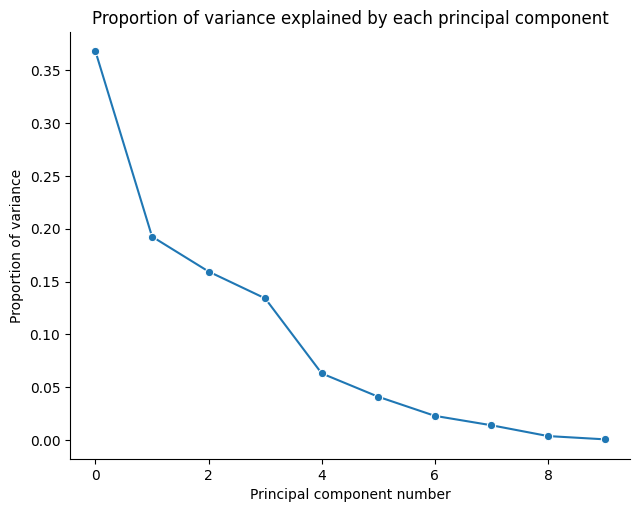

In [37]:
# Create a Pandas DataFrame from the variance explained array
explained_variance_array_df = pd.DataFrame(explained_variance_array, columns=["Variance explained"])

(
  # Create a line chart with sns.relplot
  sns.relplot(
      kind = 'line',
      data = explained_variance_array_df,
      x = explained_variance_array_df.index,
      y = "Variance explained",
      marker = 'o',
      aspect = 1.3)
  # Set the title of the plot
  .set(title = "Proportion of variance explained by each principal component")
  # Set the axis labels
  .set_axis_labels("Principal component number", "Proportion of variance")
);

Just like the elbow method used to determine the optimal number of clusters for k-means clustering, we are looking for a point where the decrease in variance levels off. This point, known as the elbow point, marks the point at which the explained variance starts to reduce significantly.

In [38]:
# Set the variable elbow to where you believe the elbow is
elbow = 6

Let's make a DataFrame containing these principle components

In [39]:
# Create a PCA object with {elbow} principal components
# We add 1 as the principal components start at 0 and not 1
pca_elbow = PCA(n_components = elbow + 1)

# Fit the PCA object to the scaled features dataframe and transform it
pca_elbow_df = pca_elbow.fit_transform(scaled_features_df)

# The dataframe now contains the principal components of the scaled features dataframe
pca_elbow_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6
student,,,,,,,
Alexandra,0.791544,-0.013019,-1.141658,0.035853,-0.155952,0.101268,-0.067188
Andrea,-0.049550,0.820885,-0.353933,0.542393,0.377203,-0.130496,-0.073656
Daniel,0.686774,0.839755,0.352403,-0.423750,-0.061842,0.240311,0.319581
Josef,0.627075,-0.944560,0.037933,-0.257967,0.107956,-0.192858,0.199884
Kaj,1.005751,-0.087092,0.307003,0.411140,-0.324927,-0.174651,-0.019193
Katherine,0.369758,-0.440530,0.342519,0.127094,0.528051,0.459197,-0.173156
Leslie,-0.340745,-0.239646,-0.294414,-0.069526,-0.068146,-0.179807,-0.015188
Merry,-0.742523,0.417591,0.151973,0.136223,-0.010156,-0.100662,0.080915
Perry,-1.035180,-0.144931,-0.214252,-0.283412,-0.436968,0.365140,-0.057370


####3.1.2.&nbsp; Cumulative explained variance
Cumulative explained variance (CEV) is calculated by summing the explained variance of each principal component. The CEV plot shows how much variance is explained by each principal component, as well as the cumulative variance explained by all principal components up to that point.

In [40]:
cumulative_sum_of_variance = np.cumsum(explained_variance_array)

cumulative_sum_of_variance

array([0.36750845, 0.55999854, 0.71946406, 0.85355318, 0.91673895,
       0.95785541, 0.98093135, 0.99511995, 0.99910157, 1.        ])

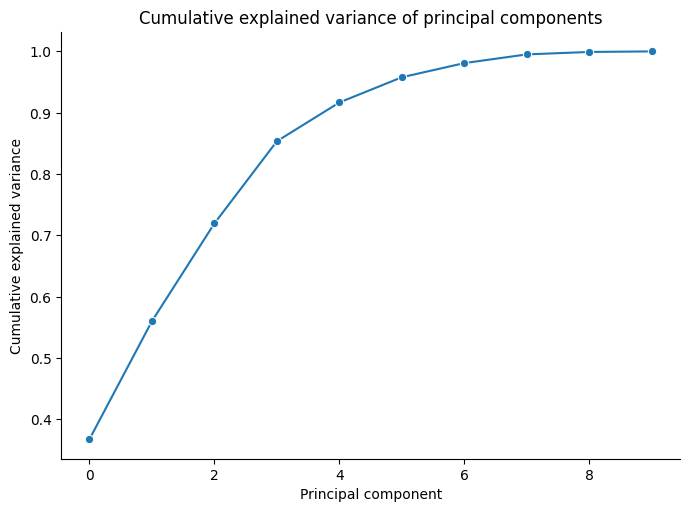

In [41]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = range(len(explained_variance_array)),  # Set the x-axis to be the principal component index
      y = cumulative_sum_of_variance,  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title = "Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

We can also look for an elbow in the cumulative variance plot to determine how many principal components to retain. However, instead of doing that, we will set a cumulative variance threshold in the PCA constructor. This threshold tells scikit-learn how many principal components to retain. For example, 0.95 tells scikit-learn that we want to retain as many principle components as contain 95% or more of the variance.

In [42]:
# Create a PCA object
pca_variance = PCA(n_components = 0.95)

Let's visualise this threshold

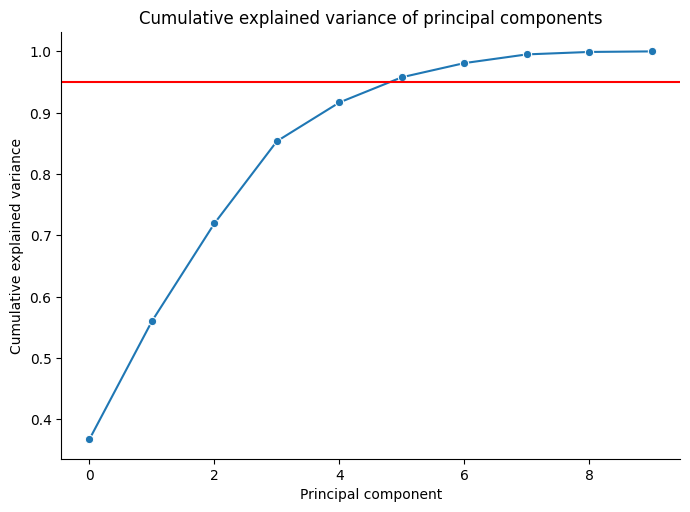

In [43]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = range(len(explained_variance_array)),  # Set the x-axis to be the principal component index
      y = cumulative_sum_of_variance,  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title="Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

# Add a horizontal red line at 0.95 on the y axis
plt.axhline(y = 0.95,
            color = 'red');

Let's apply this to our scaled data

In [44]:
# Fit the PCA object to the scaled features dataframe and transform it
pca_variance_df = pca_variance.fit_transform(scaled_features_df)

# The dataframe now contains the principal components of the scaled features dataframe
pca_variance_df

,pca0,pca1,pca2,pca3,pca4,pca5
student,,,,,,
Alexandra,0.791544,-0.013019,-1.141658,0.035853,-0.155952,0.101268
Andrea,-0.049550,0.820885,-0.353933,0.542393,0.377203,-0.130496
Daniel,0.686774,0.839755,0.352403,-0.423750,-0.061842,0.240311
Josef,0.627075,-0.944560,0.037933,-0.257967,0.107956,-0.192858
Kaj,1.005751,-0.087092,0.307003,0.411140,-0.324927,-0.174651
Katherine,0.369758,-0.440530,0.342519,0.127094,0.528051,0.459197
Leslie,-0.340745,-0.239646,-0.294414,-0.069526,-0.068146,-0.179807
Merry,-0.742523,0.417591,0.151973,0.136223,-0.010156,-0.100662
Perry,-1.035180,-0.144931,-0.214252,-0.283412,-0.436968,0.365140


###3.2.&nbsp; Using PCA on a bigger dataset
Let's look at how useful PCA can be as your datasets get bigger

Sklearn `make_blobs` creates artificial datasets with distinct clusters. Specifically, it creates a specified number of clusters, each with a defined center and standard deviation, and generates a set of random data points around these cluster centers.

In [45]:
X, _ = make_blobs(n_samples = 1000,
                  n_features = 80,
                  centers = 30,
                  random_state = 123)

blobs_df = pd.DataFrame(X)

blobs_df

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,-1.701211,-6.399239,-7.729052,2.265238,8.432041,9.277738,-3.215520,8.544695,6.099043,0.014891,...,9.396956,5.661922,2.934566,3.170368,-7.399278,-0.832894,-0.999056,-8.342735,-10.092994,-10.179048
1,6.278723,-1.685660,-8.218419,1.232155,4.975136,3.283750,-7.377526,-2.714595,-3.882671,-1.899557,...,5.466632,2.652671,-9.222847,9.538737,-7.463871,2.315972,-2.579873,8.930986,9.458209,-4.704239
2,0.362480,6.060881,8.326247,-8.100459,3.719719,5.852855,-3.622466,10.132258,-4.990926,-10.128942,...,-4.794613,-5.285732,2.524211,-0.303708,-3.738831,-8.620748,0.995726,-3.263961,-1.606649,-2.287265
3,-7.898993,7.340964,8.437767,1.638283,-10.638737,-5.494111,4.355004,6.773989,-1.184502,-2.607903,...,0.693676,2.874440,4.808158,-6.888949,7.978908,1.088713,-8.015163,3.873678,-6.091533,-9.308514
4,-1.966892,4.560141,0.305921,-9.505989,2.049690,4.833094,-3.366090,6.964881,6.073835,-0.826616,...,-6.015234,-5.711455,-4.577501,6.368909,7.408595,-10.217053,-3.956262,9.250847,0.802116,3.455974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.037868,-1.052171,-1.696614,-3.589264,1.354960,-7.171995,-6.449717,7.796660,-7.974470,9.057194,...,0.628226,8.164277,0.225216,5.006440,-8.500344,8.669795,9.208054,-4.265727,5.286935,4.811373
996,4.966277,-1.962102,-0.405020,-5.171068,1.487542,-8.193387,-5.577824,6.705522,-9.944412,7.558356,...,3.103869,9.523761,-1.618870,5.583400,-11.195325,7.614480,8.127628,-4.248268,4.068702,7.036022
997,3.113358,-6.218700,-7.158985,3.228768,3.312216,-0.032758,8.548647,4.993490,0.905350,-1.923980,...,-7.073941,8.812679,3.583802,5.988114,-8.865571,-0.392879,1.778686,-6.369937,-7.159916,2.437978
998,-3.098527,0.416230,-9.574874,6.547465,8.146674,0.221676,-4.811377,8.627207,-2.746769,2.801459,...,-7.886887,2.117376,-0.069422,-7.265878,-9.514596,-1.640425,2.925496,-2.944405,-2.298123,6.162888


Scale our created data

In [46]:
# Initialise the transformer (optionally, set parameters)
my_min_max = MinMaxScaler()

# Use the transformer to transform the data
scaled_blobs_df = my_min_max.fit_transform(blobs_df)

Perform PCA on our scaled data

In [47]:
# Initialise the PCA object
pca = PCA()

# Fit the PCA object to the data
pca.fit(scaled_blobs_df)

PCA()

Extract the explained variance for each Principal Component

In [48]:
explained_blobs_variance_array = pca.explained_variance_ratio_

Plot the cumulative sum of the extracted variances

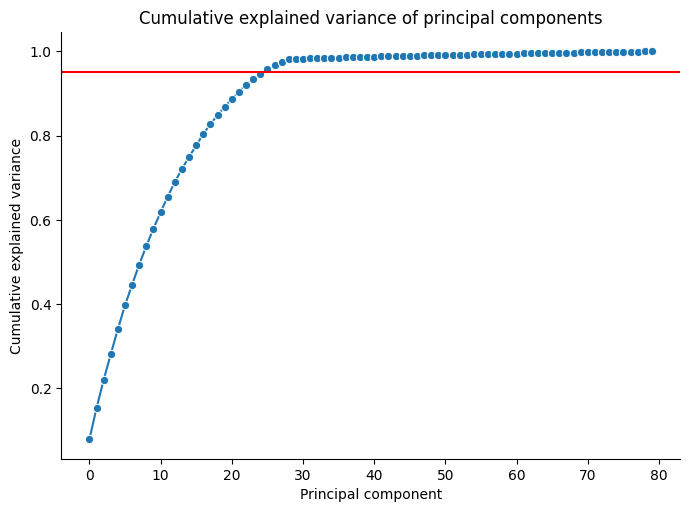

In [49]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = range(len(explained_blobs_variance_array)),  # Set the x-axis to be the principal component index
      y = np.cumsum(explained_blobs_variance_array),  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title = "Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

# Add a horizontal red line at 0.95 on the y axis
plt.axhline(y = 0.95,
            color = 'red');

Find out how many components make up 95% of the variance

In [50]:
# Calculate the cumulative sum
cumulative_sum = np.cumsum(explained_blobs_variance_array)

# Find the index where the cumulative sum reaches 0.95
index = np.searchsorted(cumulative_sum, 0.95)

# Print the number of components required to reach 0.95 variance
print(index + 1)

26


In this example, we were able to successfully reduce an 80-dimensional dataset to a more manageable 26-dimensional representation. This significant reduction in dimensionality not only helps to minimize noise but also substantially improves training times.

---
##4.&nbsp; Challenge: apply this to the spotify dataset 😃
Use PCA to reduce noise and the dimensionality of the Spotify dataset before clustering the songs. This will help to identify the most important features of the songs, and it will also make the clustering process more efficient.

Once you have clustered the songs using the selected principal components, you can analyse the clusters to identify groups of similar songs. For example, you could look for clusters of songs with similar genres, tempos, or moods.

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
path = "/content/drive/MyDrive/Colab Notebooks/Unsupervised ML/spotify_10_songs.csv"
df = pd.read_csv(path)
df.head(10)

,song_name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html
0,My Band ...,D12,0.851,0.84900,1,-3.383,0,0.0828,0.49700,0.000002,0.1160,0.8440,120.014,298773,4,4XHQyvbrBsQaaBUW1VvmsL,https://open.spotify.com/track/4XHQyvbrBsQaaBU...
1,The Real Slim Shady ...,Eminem,0.949,0.66100,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.7600,104.504,284200,4,3yfqSUWxFvZELEM4PmlwIR,https://open.spotify.com/track/3yfqSUWxFvZELEM...
2,Águas De Março ...,Antônio Carlos Jobim,0.642,0.33900,3,-15.503,1,0.1400,0.85400,0.000000,0.1050,0.4910,143.418,212400,4,1y7OxO5i6sfrHXAmUM77YG,https://open.spotify.com/track/1y7OxO5i6sfrHXA...
3,The Girl From Ipanema ...,Stan Getz,0.641,0.14000,8,-16.790,1,0.0390,0.86700,0.001660,0.1050,0.3880,129.318,317987,4,3898C4AbdbptwYet6547e5,https://open.spotify.com/track/3898C4AbdbptwYe...
4,"Paint It, Black ...",The Rolling Stones,0.464,0.79500,1,-9.267,1,0.0926,0.04930,0.002440,0.3990,0.6120,158.691,202267,4,63T7DJ1AFDD6Bn8VzG6JE8,https://open.spotify.com/track/63T7DJ1AFDD6Bn8...
5,Sultans Of Swing ...,Dire Straits,0.733,0.79400,5,-10.023,1,0.0307,0.06140,0.036700,0.3300,0.9310,148.174,348624,4,6cr6UDpkjEaMQ80OjWqEBQ,https://open.spotify.com/track/6cr6UDpkjEaMQ80...
6,Space Raiders - Charlotte de Witte Remix ...,Eats Everything,0.749,0.73100,4,-10.865,1,0.1080,0.00314,0.867000,0.1110,0.0598,131.997,438720,4,4F8OK7mNa51mKqgHqWQiYm,https://open.spotify.com/track/4F8OK7mNa51mKqg...
7,In Silence ...,Amelie Lens,0.736,0.84500,1,-12.017,1,0.0377,0.00548,0.901000,0.1110,0.1980,128.009,393740,4,2vfSCFvMbpf4hwxt22Wx7b,https://open.spotify.com/track/2vfSCFvMbpf4hwx...
8,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and ...",Johannes Brahms,0.184,0.00833,3,-33.503,1,0.0519,0.98900,0.596000,0.1040,0.2110,61.541,109800,3,59cPOVxrn3Yjwydl1pullI,https://open.spotify.com/track/59cPOVxrn3Yjwyd...
9,Nocturne en mi bémol majeur opus 9 n°2: Ballad...,Frédéric Chopin,0.387,0.04510,3,-24.698,1,0.0364,0.99000,0.913000,0.1120,0.0710,61.494,268427,4,7n92QzQomRCLlciO14X0kd,https://open.spotify.com/track/7n92QzQomRCLlci...


# Step 1 - Choose features

In [53]:
# features already contains only numeric columns from the Spotify dataset

df.columns = df.columns.str.strip()
features = df.select_dtypes(include="number")
features = features.drop(columns=["key", "time_signature"])

#Step 1 – Choose features

## What I did
I selected only the numeric features from the Spotify dataset and removed the columns key and time_signature.

## Why
Clustering algorithms such as K-Means work with numeric variables. However, key and time_signature are encoded as numbers but do not represent continuous numeric relationships, which could distort the distance calculations.

## Result
The dataset now contains only meaningful numeric audio features that can be used for scaling and PCA.

# Step 2 - Scaling



In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 2 – Scaling

## What I did
I applied StandardScaler to standardize the selected features.

## Why
The Spotify features have different ranges (for example tempo, loudness, and danceability). Scaling ensures that all features contribute equally to the clustering algorithm.

## Result
All features are transformed to a similar scale with mean ≈ 0 and standard deviation ≈ 1.

# Step 3 - PCA




In [55]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

# Step 3 – PCA

## What I did
I applied Principal Component Analysis (PCA) and reduced the dataset to two principal components.

## Why
PCA reduces dimensionality and noise by combining correlated features into new components that capture the most important information in the dataset. Using two components also allows me to visualize the songs in a 2-dimensional plot.

## Result
The dataset was transformed into two new variables (PC1 and PC2) that summarize the most important information from the original features.

# Step 4 - Runnig of KMeans on PCA

In [56]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(pca_features)

labels = kmeans.labels_


# Step 4 – Running K-Means on PCA

## What I did
I applied the K-Means clustering algorithm to the PCA-transformed dataset with k = 3 clusters.

## Why
K-Means groups songs based on similarity in their audio characteristics. Using PCA features can improve clustering performance by reducing noise and redundancy.

## Result
Each song was assigned to one of three clusters.

In [57]:
df["cluster"] = labels

df[["song_name", "artist", "cluster"]]

,song_name,artist,cluster
0,My Band ...,D12,2
1,The Real Slim Shady ...,Eminem,2
2,Águas De Março ...,Antônio Carlos Jobim,0
3,The Girl From Ipanema ...,Stan Getz,0
4,"Paint It, Black ...",The Rolling Stones,2
5,Sultans Of Swing ...,Dire Straits,2
6,Space Raiders - Charlotte de Witte Remix ...,Eats Everything,1
7,In Silence ...,Amelie Lens,1
8,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and ...",Johannes Brahms,0
9,Nocturne en mi bémol majeur opus 9 n°2: Ballad...,Frédéric Chopin,0


# Step 5- Adding Clustre to Dataset

In [58]:
df["cluster"] = labels

In [59]:
import pandas as pd

pca_df = pd.DataFrame(pca_features, columns=["PC1","PC2"])

# Step 5 – Adding cluster to dataset

## What I did
I added the cluster labels generated by K-Means to the original dataset.

## Why
Adding the cluster labels allows us to identify which songs belong to each group and analyze the characteristics of the clusters.

## Result
The dataset now includes a new column called cluster that shows the group assignment for each song.

# Step 6 - Plot

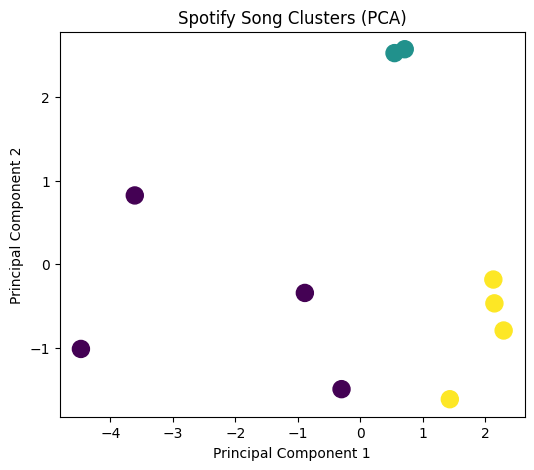

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    pca_features["pca0"],
    pca_features["pca1"],
    c=labels,
    cmap="viridis",
    s=150
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Spotify Song Clusters (PCA)")

plt.show()


# Step 6 – Plot

## What I did
I created a scatter plot using the two principal components.

## Why
This visualization helps us see how the songs are grouped in the reduced feature space and how the clusters are separated.

## Result
Each point in the plot represents a song, and the colors indicate the cluster to which the song belongs.

# Create a PCA object with {elbow} principal components

In [61]:
from sklearn.decomposition import PCA
import pandas as pd

# choose the elbow point from the cumulative explained variance plot
elbow = 3

# create PCA object with {elbow} principal components
# we add 1 because principal components start at 0 and not 1
pca_elbow = PCA(n_components=elbow + 1)

# fit the PCA object to the scaled features and transform it
pca_elbow_df = pca_elbow.fit_transform(scaled_features)

# convert to DataFrame
pca_elbow_df = pd.DataFrame(pca_elbow_df)

pca_elbow_df

,pca0,pca1,pca2,pca3
0,2.294661,-0.795302,-1.861799,0.123799
1,2.129959,-0.184465,-2.447997,-0.460684
2,-0.299722,-1.498269,0.156475,2.296436
3,-0.886603,-0.345002,-0.256486,-0.217683
4,1.433448,-1.618856,2.445709,-0.042142
5,2.146992,-0.470029,1.361428,-1.674323
6,0.711828,2.575755,0.677081,1.456923
7,0.548205,2.529147,0.475698,-0.457009
8,-4.470471,-1.016373,-0.173229,-0.419215
9,-3.608298,0.823393,-0.376880,-0.606100


### Each value represents the position of a song along a principal component. These components are combinations of the original Spotify audio features, allowing the songs to be represented in a reduced feature space.

# What I did

I applied PCA using the number of components determined from the elbow point of the cumulative explained variance plot. The elbow was identified at component 3, so I used elbow + 1 principal components and transformed the scaled dataset.

# Why

Instead of choosing an arbitrary number of components, the elbow method helps determine how many principal components are needed to retain most of the important information in the dataset.

# Result

The dataset was reduced to four principal components (pca0, pca1, pca2, pca3). These components capture most of the variance of the original features while reducing dimensionality.

## Difference from PCA(n_components = 2)

### PCA(n_components = 2)

- The number of components is chosen manually.

- Used mainly for visualization in 2D plots.

- Keeps less information from the original dataset.

### PCA(n_components = elbow + 1)

- The number of components is determined using the explained variance elbow method.

- Keeps more information from the dataset.

- Better for modeling and clustering, but harder to visualize directly.

In [62]:
!pip install gdown

In [63]:
import gdown

In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd

df = pd.read_csv("3_spotify_5000_songs.csv")
df.head()

In [ ]:
# features already contains only numeric columns from the Spotify dataset

df.columns = df.columns.str.strip()
features = df.select_dtypes(include="number")
features = features.drop(columns=["key", "time_signature"])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
scaler = MinMaxScaler()
songs_selected_scaled = scaler.fit_transform(features)
songs_selected_scaled.sample(10)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

# Fit the PCA object to the scaled features dataframe and transform it
pca_features = pca.fit_transform(scaled_features)

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

k_values = [20, 30, 40, 50, 60, 70, 80, 90, 100]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_features)

    labels = kmeans.labels_

    cluster_sizes = np.bincount(labels)

    print(f"\nk = {k}")
    print("Cluster sizes:")
    print(cluster_sizes)
    print("Min size:", cluster_sizes.min())
    print("Max size:", cluster_sizes.max())

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=91, random_state=42, n_init=10)

labels = kmeans.fit_predict(pca_features)


df["cluster"] = labels


cluster_sizes = np.bincount(labels)

print("Cluster sizes:")
print(cluster_sizes)

print("Min size:", cluster_sizes.min())
print("Max size:", cluster_sizes.max())

In [ ]:

# cluster 51 = Danceable, high energy, loud, upbeat songs
df.loc[df['cluster'] == 51].sample(5)

In [ ]:
# cluster 34 = High energy, very loud, dark songs with low danceability
df.loc[df['cluster'] == 34].sample(5)

In [ ]:
# cluster 7 = slow, instrumental, low energy, quiet
df.loc[df['cluster'] == 7].sample(5)

In [ ]:
# cluster 7 = It doesn’t always work well- Mostly dark and moody but high variability in energy, tempo
df.loc[df['cluster'] == 90].sample(5)

In [ ]:
#get centroids
centroids_pca = kmeans.cluster_centers_

#transform them back to scaled feature space
centroids_scaled = pca.inverse_transform(centroids_pca)

#undo scaling to original units
centroids_original = scaler.inverse_transform(centroids_scaled)

#put into dataframe
feature_names = features.columns

centroid_df = pd.DataFrame(
    centroids_original,
    columns=feature_names
)

centroid_df.index.name = "cluster"

centroid_df

In [ ]:
# Look at the centroid values to interpret the characteristics of each cluster

centroid_df.head()

In [ ]:
songs_with_cluster = df.copy()
songs_with_cluster["cluster"] = kmeans.labels_

songs_with_cluster.head()

In [ ]:
centroid_df.sort_values("energy", ascending=False).head()

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(pca_features.iloc[:,0], pca_features.iloc[:,1], c=kmeans.labels_, s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (PCA projection)")
plt.show()